<a href="https://colab.research.google.com/github/OmarAbouraia/MNIST-Classification-ML/blob/main/Phase2_Multiclass_Classification_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1. Imports & Setup
# =========================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tensorflow.keras.datasets import mnist

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# =========================
# 2. Problem Definition
# =========================

print("Phase 2: Multi-class Classification (0–9)")
print("Dataset: MNIST")
print("Input: 28x28 grayscale image")
print("Output: digit class (0 → 9)")

Phase 2: Multi-class Classification (0–9)
Dataset: MNIST
Input: 28x28 grayscale image
Output: digit class (0 → 9)


In [ ]:
# =========================
# 2. Load MNIST Dataset
# =========================

(X_train_full, y_train_full), (X_test_img, y_test) = mnist.load_data()

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test_img.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [ ]:
# =========================
# 3. Normalize & Flatten
# =========================

X_train_full = X_train_full.astype("float32") / 255.0
X_test_img = X_test_img.astype("float32") / 255.0

X_train_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test_img.reshape(X_test_img.shape[0], -1)

print("Flattened train:", X_train_flat.shape)
print("Flattened test:", X_test_flat.shape)

Flattened train: (60000, 784)
Flattened test: (10000, 784)


In [ ]:
# =========================
# 4. Train / Validation Split
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_flat,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Train flat:", X_train.shape)
print("Validation flat:", X_val.shape)
print("Train image:", X_train_img.shape)
print("Validation image:", X_val_img.shape)

Train flat: (48000, 784)
Validation flat: (12000, 784)
Train image: (48000, 28, 28)
Validation image: (12000, 28, 28)


In [ ]:
# =========================
# 5. Feature Scaling
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_flat)

print("Scaling completed.")

Scaling completed.


In [ ]:
# =========================
# 6. Evaluation Function
# =========================

def evaluate_model(model, X_data, y_true, dataset_name="Dataset"):
    y_pred = model.predict(X_data)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\nEvaluation on {dataset_name}")
    print("-" * 45)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

In [ ]:
# =========================
# 7. Softmax Regression From Scratch
# =========================

class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, num_iterations=1000, reg_strength=0.0):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.reg_strength = reg_strength
        self.weights = None
        self.bias = None
        self.loss_history = []

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y):
        num_classes = 10
        one_hot_y = np.zeros((len(y), num_classes))
        one_hot_y[np.arange(len(y)), y] = 1
        return one_hot_y

    def compute_loss(self, y_one_hot, y_pred):
        epsilon = 1e-9
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        cross_entropy = -np.mean(np.sum(y_one_hot * np.log(y_pred), axis=1))
        l2_penalty = self.reg_strength * np.sum(self.weights ** 2)

        return cross_entropy + l2_penalty

    def fit(self, X, y):
        n_samples, n_features = X.shape
        num_classes = 10

        self.weights = np.zeros((n_features, num_classes))
        self.bias = np.zeros(num_classes)

        y_one_hot = self.one_hot(y)

        for i in range(self.num_iterations):
            logits = np.dot(X, self.weights) + self.bias
            y_pred = self.softmax(logits)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_one_hot))
            db = (1 / n_samples) * np.sum(y_pred - y_one_hot, axis=0)

            dw += 2 * self.reg_strength * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self.compute_loss(y_one_hot, y_pred)
            self.loss_history.append(loss)

            if i % 500 == 0:
                print(f"Iteration {i}: Loss = {loss:.4f}")

    def predict_proba(self, X):
        logits = np.dot(X, self.weights) + self.bias
        return self.softmax(logits)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

Iteration 0: Loss = 2.3026
Iteration 500: Loss = 0.2772

Evaluation on Validation - Softmax Baseline
---------------------------------------------
Accuracy : 0.9183
Precision: 0.9176
Recall   : 0.9173
F1-score : 0.9173

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1185
           1       0.93      0.97      0.95      1348
           2       0.92      0.89      0.91      1192
           3       0.91      0.88      0.90      1226
           4       0.92      0.93      0.92      1168
           5       0.89      0.88      0.89      1084
           6       0.95      0.95      0.95      1184
           7       0.93      0.92      0.93      1253
           8       0.88      0.87      0.88      1170
           9       0.89      0.90      0.90      1190

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

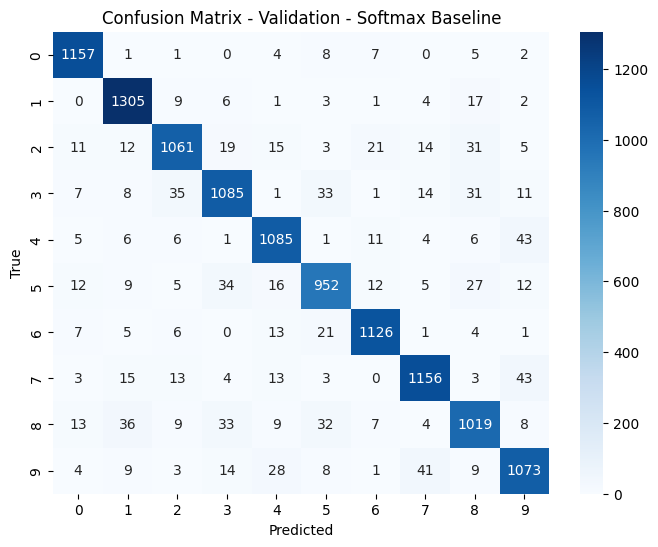

{'Accuracy': 0.91825,
 'Precision': 0.9176392228975627,
 'Recall': 0.9172952002027653,
 'F1-score': 0.9173390934598606}

In [ ]:
# =========================
# 8. Baseline Softmax Regression
# =========================

softmax_baseline = SoftmaxRegression(
    learning_rate=0.1,
    num_iterations=1000,
    reg_strength=0.0
)

softmax_baseline.fit(X_train_scaled, y_train)

softmax_val_results = evaluate_model(
    softmax_baseline,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Softmax Baseline"
)

softmax_val_results

In [ ]:
# =========================
# 11. L2 Regularization and Bias-Variance Analysis
# =========================

reg_results = []

for reg in [0.0, 0.0001, 0.001, 0.01]:
    model = SoftmaxRegression(
        learning_rate=0.1,
        num_iterations=800,
        reg_strength=reg
    )

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    gap = train_acc - val_acc

    if train_acc < 0.85 and val_acc < 0.85:
        diagnosis = "Underfitting / High Bias"
    elif gap > 0.05:
        diagnosis = "Overfitting / High Variance"
    else:
        diagnosis = "Balanced"

    reg_results.append({
        "Model": "Softmax Regression",
        "L2 Regularization": reg,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Train-Val Gap": gap,
        "Diagnosis": diagnosis
    })

reg_results_df = pd.DataFrame(reg_results)
reg_results_df

Iteration 0: Loss = 2.3026
Iteration 500: Loss = 0.2772
Iteration 0: Loss = 2.3026
Iteration 500: Loss = 0.2787
Iteration 0: Loss = 2.3027
Iteration 500: Loss = 0.2921
Iteration 0: Loss = 2.3034
Iteration 500: Loss = 0.3848


,Model,L2 Regularization,Train Accuracy,Validation Accuracy,Train-Val Gap,Diagnosis
0,Softmax Regression,0.0000,0.925750,0.916583,0.009167,Balanced
1,Softmax Regression,0.0001,0.925667,0.916500,0.009167,Balanced
2,Softmax Regression,0.0010,0.925083,0.916000,0.009083,Balanced
3,Softmax Regression,0.0100,0.918333,0.912417,0.005917,Balanced


In [ ]:
# =========================
# 12. Hyperparameter Tuning with Cross-Validation
# =========================

def cross_validate_softmax(X, y, learning_rates, reg_values, k_folds=3):
    skf = StratifiedKFold(
        n_splits=k_folds,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    results = []

    for lr in learning_rates:
        for reg in reg_values:
            fold_scores = []

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_va = X[train_idx], X[val_idx]
                y_tr, y_va = y[train_idx], y[val_idx]

                model = SoftmaxRegression(
                    learning_rate=lr,
                    num_iterations=500,
                    reg_strength=reg
                )

                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_va)

                fold_scores.append(f1_score(y_va, y_pred, average="macro"))

            results.append({
                "Learning Rate": lr,
                "L2 Regularization": reg,
                "Mean CV F1-score": np.mean(fold_scores),
                "Std CV F1-score": np.std(fold_scores)
            })

    return pd.DataFrame(results).sort_values(
        by="Mean CV F1-score",
        ascending=False
    ).reset_index(drop=True)


# Use a subset to make cross-validation faster
cv_subset_size = 10000
X_cv = X_train_scaled[:cv_subset_size]
y_cv = y_train[:cv_subset_size]

softmax_cv_results = cross_validate_softmax(
    X_cv,
    y_cv,
    learning_rates=[0.05, 0.1],
    reg_values=[0.0, 0.0001, 0.001],
    k_folds=3
)

softmax_cv_results

Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3026
Iteration 0: Loss = 2.3027
Iteration 0: Loss = 2.3027
Iteration 0: Loss = 2.3027


,Learning Rate,L2 Regularization,Mean CV F1-score,Std CV F1-score
0,0.10,0.0010,0.898694,0.005492
1,0.10,0.0000,0.898534,0.005056
2,0.10,0.0001,0.898534,0.005056
3,0.05,0.0000,0.893858,0.004847
4,0.05,0.0001,0.893858,0.004847
5,0.05,0.0010,0.893329,0.005166


In [ ]:
# =========================
# Best Softmax Hyperparameters
# =========================

best_softmax_lr = softmax_cv_results.iloc[0]["Learning Rate"]
best_softmax_reg = softmax_cv_results.iloc[0]["L2 Regularization"]

print("Best Softmax Learning Rate:", best_softmax_lr)
print("Best Softmax L2 Regularization:", best_softmax_reg)

Best Softmax Learning Rate: 0.1
Best Softmax L2 Regularization: 0.001


Iteration 0: Loss = 2.3027
Iteration 500: Loss = 0.2921

Evaluation on Validation - Tuned Softmax Regression
---------------------------------------------
Accuracy : 0.9173
Precision: 0.9167
Recall   : 0.9163
F1-score : 0.9163

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1185
           1       0.92      0.97      0.95      1348
           2       0.92      0.89      0.91      1192
           3       0.91      0.88      0.89      1226
           4       0.92      0.93      0.92      1168
           5       0.89      0.88      0.89      1084
           6       0.95      0.95      0.95      1184
           7       0.93      0.92      0.93      1253
           8       0.89      0.87      0.88      1170
           9       0.89      0.90      0.90      1190

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92  

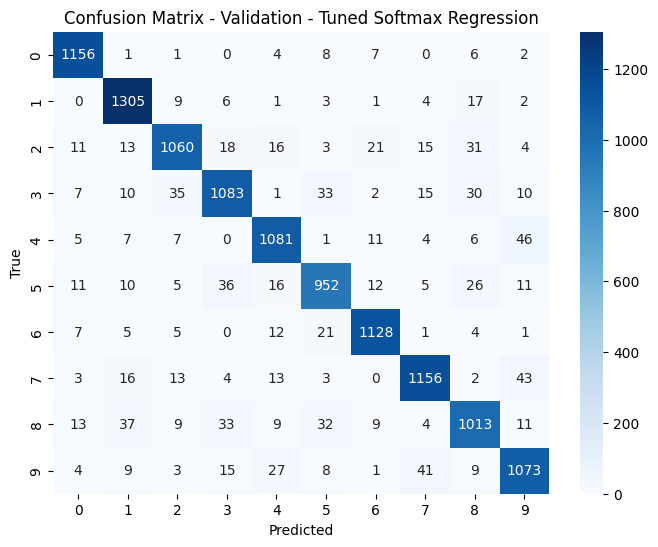

{'Accuracy': 0.91725,
 'Precision': 0.9166957385285782,
 'Recall': 0.9162774199153045,
 'F1-score': 0.9163430219709454}

In [ ]:
# =========================
# Train Tuned Softmax Regression
# =========================

tuned_softmax = SoftmaxRegression(
    learning_rate=best_softmax_lr,
    num_iterations=1000,
    reg_strength=best_softmax_reg
)

tuned_softmax.fit(X_train_scaled, y_train)

tuned_softmax_val_results = evaluate_model(
    tuned_softmax,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Tuned Softmax Regression"
)

tuned_softmax_val_results

In [ ]:
# =========================
# 13. Linear SVM From Scratch
# =========================

class LinearSVMFromScratch:
    def __init__(self, learning_rate=0.001, num_iterations=1000, reg_strength=0.001):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.reg_strength = reg_strength
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        num_classes = len(np.unique(y))

        self.weights = 0.001 * np.random.randn(n_features, num_classes)
        self.bias = np.zeros(num_classes)

        for iteration in range(self.num_iterations):
            scores = np.dot(X, self.weights) + self.bias
            correct_scores = scores[np.arange(n_samples), y].reshape(-1, 1)

            margins = np.maximum(0, scores - correct_scores + 1)
            margins[np.arange(n_samples), y] = 0

            loss = np.mean(np.sum(margins, axis=1)) + self.reg_strength * np.sum(self.weights ** 2)
            self.loss_history.append(loss)

            binary = (margins > 0).astype(float)
            row_sum = np.sum(binary, axis=1)
            binary[np.arange(n_samples), y] = -row_sum

            dw = (1 / n_samples) * np.dot(X.T, binary) + 2 * self.reg_strength * self.weights
            db = (1 / n_samples) * np.sum(binary, axis=0)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if iteration % 500 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.4f}")

    def predict(self, X):
        scores = np.dot(X, self.weights) + self.bias
        return np.argmax(scores, axis=1)

Iteration 0: Loss = 9.0784
Iteration 500: Loss = 0.5979
Iteration 1000: Loss = 0.5147

Evaluation on Validation - Linear SVM From Scratch
---------------------------------------------
Accuracy : 0.9077
Precision: 0.9073
Recall   : 0.9067
F1-score : 0.9067

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1185
           1       0.92      0.96      0.94      1348
           2       0.92      0.87      0.89      1192
           3       0.90      0.87      0.89      1226
           4       0.90      0.93      0.91      1168
           5       0.89      0.86      0.87      1084
           6       0.94      0.94      0.94      1184
           7       0.93      0.92      0.92      1253
           8       0.86      0.86      0.86      1170
           9       0.88      0.90      0.89      1190

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg    

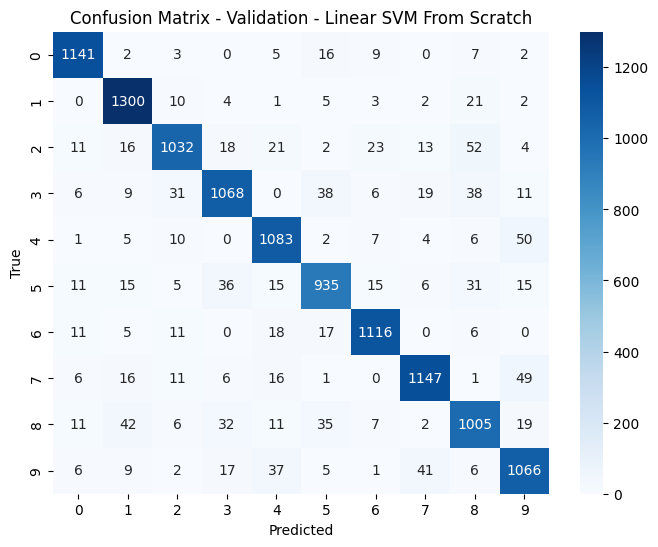

{'Accuracy': 0.90775,
 'Precision': 0.9073085793052446,
 'Recall': 0.9066673744982587,
 'F1-score': 0.9067476291896612}

In [ ]:
# =========================
# 14. Train Linear SVM From Scratch
# =========================

svm_model = LinearSVMFromScratch(
    learning_rate=0.001,
    num_iterations=1500,
    reg_strength=0.001
)

svm_model.fit(X_train_scaled, y_train)

svm_val_results = evaluate_model(
    svm_model,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Linear SVM From Scratch"
)

svm_val_results

In [ ]:
# =========================
# SVM Hyperparameter Tuning with Cross-Validation
# =========================

def cross_validate_svm(X, y, learning_rates, reg_values, k_folds=3):
    skf = StratifiedKFold(
        n_splits=k_folds,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    results = []

    for lr in learning_rates:
        for reg in reg_values:
            fold_scores = []

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_va = X[train_idx], X[val_idx]
                y_tr, y_va = y[train_idx], y[val_idx]

                model = LinearSVMFromScratch(
                    learning_rate=lr,
                    num_iterations=500,
                    reg_strength=reg
                )

                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_va)

                fold_scores.append(f1_score(y_va, y_pred, average="macro"))

            results.append({
                "Learning Rate": lr,
                "Regularization": reg,
                "Mean CV F1-score": np.mean(fold_scores),
                "Std CV F1-score": np.std(fold_scores)
            })

    return pd.DataFrame(results).sort_values(
        by="Mean CV F1-score",
        ascending=False
    ).reset_index(drop=True)


# Use subset to make CV faster
cv_subset_size = 10000
X_cv = X_train_scaled[:cv_subset_size]
y_cv = y_train[:cv_subset_size]

svm_cv_results = cross_validate_svm(
    X_cv,
    y_cv,
    learning_rates=[0.0005, 0.001],
    reg_values=[0.0001, 0.001, 0.01],
    k_folds=3
)

svm_cv_results

Iteration 0: Loss = 8.9962
Iteration 0: Loss = 9.0323
Iteration 0: Loss = 9.0046
Iteration 0: Loss = 9.0177
Iteration 0: Loss = 8.9990
Iteration 0: Loss = 9.0258
Iteration 0: Loss = 8.9366
Iteration 0: Loss = 8.9768
Iteration 0: Loss = 9.0146
Iteration 0: Loss = 9.0031
Iteration 0: Loss = 8.9874
Iteration 0: Loss = 8.9601
Iteration 0: Loss = 8.9387
Iteration 0: Loss = 9.0073
Iteration 0: Loss = 8.9661
Iteration 0: Loss = 8.9805
Iteration 0: Loss = 9.0001
Iteration 0: Loss = 8.9585


,Learning Rate,Regularization,Mean CV F1-score,Std CV F1-score
0,0.0010,0.0001,0.882397,0.006217
1,0.0010,0.0100,0.881610,0.005268
2,0.0010,0.0010,0.881354,0.005023
3,0.0005,0.0010,0.874419,0.007565
4,0.0005,0.0100,0.874199,0.006571
5,0.0005,0.0001,0.873736,0.006717


In [ ]:
# =========================
# Best SVM Hyperparameters
# =========================

best_svm_lr = svm_cv_results.iloc[0]["Learning Rate"]
best_svm_reg = svm_cv_results.iloc[0]["Regularization"]

print("Best SVM Learning Rate:", best_svm_lr)
print("Best SVM Regularization:", best_svm_reg)

Best SVM Learning Rate: 0.001
Best SVM Regularization: 0.0001


Iteration 0: Loss = 8.9754
Iteration 500: Loss = 0.5964
Iteration 1000: Loss = 0.5132

Evaluation on Validation - Tuned Linear SVM
---------------------------------------------
Accuracy : 0.9067
Precision: 0.9062
Recall   : 0.9056
F1-score : 0.9056

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1185
           1       0.91      0.96      0.94      1348
           2       0.92      0.86      0.89      1192
           3       0.90      0.87      0.89      1226
           4       0.89      0.93      0.91      1168
           5       0.88      0.86      0.87      1084
           6       0.94      0.94      0.94      1184
           7       0.93      0.91      0.92      1253
           8       0.86      0.86      0.86      1170
           9       0.87      0.89      0.88      1190

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91

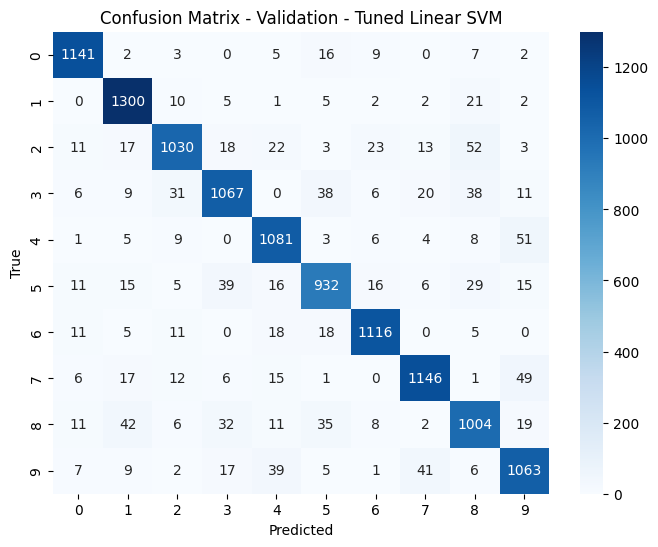

{'Accuracy': 0.9066666666666666,
 'Precision': 0.9061983610702737,
 'Recall': 0.905552658165101,
 'F1-score': 0.9056317744551124}

In [ ]:
# =========================
# Train Tuned Linear SVM
# =========================

tuned_svm = LinearSVMFromScratch(
    learning_rate=best_svm_lr,
    num_iterations=1500,
    reg_strength=best_svm_reg
)

tuned_svm.fit(X_train_scaled, y_train)

tuned_svm_val_results = evaluate_model(
    tuned_svm,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Tuned Linear SVM"
)

tuned_svm_val_results

In [ ]:
# =========================
# Compare Tuned Models
# =========================

tuned_model_comparison_df = pd.DataFrame([
    {
        "Model": "Softmax Regression",
        "Feature Type": "Raw Pixels",
        "Learning Rate": best_softmax_lr,
        "Regularization": best_softmax_reg,
        **tuned_softmax_val_results
    },
    {
        "Model": "Linear SVM",
        "Feature Type": "Raw Pixels",
        "Learning Rate": best_svm_lr,
        "Regularization": best_svm_reg,
        **tuned_svm_val_results
    }
])

tuned_model_comparison_df = tuned_model_comparison_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

tuned_model_comparison_df

,Model,Feature Type,Learning Rate,Regularization,Accuracy,Precision,Recall,F1-score
0,Softmax Regression,Raw Pixels,0.100,0.0010,0.917250,0.916696,0.916277,0.916343
1,Linear SVM,Raw Pixels,0.001,0.0001,0.906667,0.906198,0.905553,0.905632


In [ ]:
# =========================
# 15. Random Forest From Scratch
# =========================

class SimpleDecisionTree:
    def __init__(self, max_depth=10, min_samples_split=10, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.tree = None

    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def best_split(self, X, y):
        n_samples, n_features = X.shape

        if self.max_features is None:
            feature_indices = np.arange(n_features)
        else:
            feature_indices = np.random.choice(n_features, self.max_features, replace=False)

        best_feature = None
        best_threshold = None
        best_gini = float("inf")

        for feature in feature_indices:
            thresholds = np.percentile(X[:, feature], [25, 50, 75])

            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                    continue

                left_gini = self.gini(y[left_idx])
                right_gini = self.gini(y[right_idx])

                weighted_gini = (
                    np.sum(left_idx) * left_gini +
                    np.sum(right_idx) * right_gini
                ) / n_samples

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def build_tree(self, X, y, depth):
        if (
            depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1
        ):
            return self.majority_class(y)

        feature, threshold = self.best_split(X, y)

        if feature is None:
            return self.majority_class(y)

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self.build_tree(X[left_idx], y[left_idx], depth + 1),
            "right": self.build_tree(X[right_idx], y[right_idx], depth + 1)
        }

    def fit(self, X, y):
        self.tree = self.build_tree(X, y, depth=0)

    def predict_one(self, x, node):
        if not isinstance(node, dict):
            return node

        if x[node["feature"]] <= node["threshold"]:
            return self.predict_one(x, node["left"])
        else:
            return self.predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])


class RandomForestFromScratch:
    def __init__(self, n_trees=5, max_depth=8, min_samples_split=10, max_features=30):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]

        for i in range(self.n_trees):
            print(f"Training tree {i + 1}/{self.n_trees}")

            sample_indices = np.random.choice(n_samples, n_samples, replace=True)

            X_sample = X[sample_indices]
            y_sample = y[sample_indices]

            tree = SimpleDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        final_predictions = []

        for sample_preds in tree_predictions.T:
            values, counts = np.unique(sample_preds, return_counts=True)
            final_predictions.append(values[np.argmax(counts)])

        return np.array(final_predictions)

Training tree 1/5
Training tree 2/5
Training tree 3/5
Training tree 4/5
Training tree 5/5

Evaluation on Validation - Random Forest (Raw Features)
---------------------------------------------
Accuracy : 0.8340
Precision: 0.8350
Recall   : 0.8308
F1-score : 0.8306

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1185
           1       0.85      0.96      0.90      1348
           2       0.80      0.85      0.82      1192
           3       0.74      0.81      0.77      1226
           4       0.83      0.85      0.84      1168
           5       0.83      0.67      0.74      1084
           6       0.90      0.89      0.89      1184
           7       0.93      0.83      0.88      1253
           8       0.82      0.71      0.76      1170
           9       0.80      0.80      0.80      1190

    accuracy                           0.83     12000
   macro avg       0.83      0.83      0.83     12000
weighte

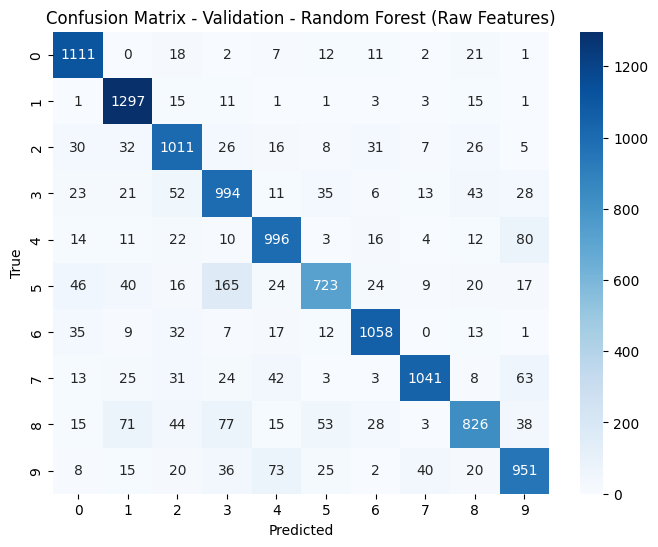

{'Accuracy': 0.834,
 'Precision': 0.8349979343054764,
 'Recall': 0.8307883610324577,
 'F1-score': 0.8305529345691302}

In [ ]:
# =========================
# 16. Train Random Forest From Scratch (RAW FEATURES)
# =========================

# Use a subset to make training faster
rf_train_size = 10000

X_rf_train = X_train_scaled[:rf_train_size]
y_rf_train = y_train[:rf_train_size]

random_forest = RandomForestFromScratch(
    n_trees=5,
    max_depth=8,
    min_samples_split=10,
    max_features=50   # increased since raw has 784 features
)

random_forest.fit(X_rf_train, y_rf_train)

rf_val_results = evaluate_model(
    random_forest,
    X_val_scaled,
    y_val,
    dataset_name="Validation - Random Forest (Raw Features)"
)

rf_val_results

In [ ]:
# =========================
# 17. Pretrained CNN Feature Extraction
# =========================

def prepare_for_cnn(images):
    images = np.expand_dims(images, axis=-1)
    images = tf.image.resize(images, (96, 96))
    images = tf.image.grayscale_to_rgb(images)
    images = preprocess_input(images)
    return images

cnn_feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(96, 96, 3)
)

cnn_feature_extractor.trainable = False

print("CNN feature extractor loaded.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN feature extractor loaded.


In [ ]:
# =========================
# 18. Extract CNN Features
# =========================

# To keep runtime reasonable, use a subset for CNN features
cnn_train_size = 15000

X_cnn_train_img = X_train_img[:cnn_train_size]
y_cnn_train = y_train_img[:cnn_train_size]

X_cnn_val_img = X_val_img
y_cnn_val = y_val_img

X_train_cnn_input = prepare_for_cnn(X_cnn_train_img)
X_val_cnn_input = prepare_for_cnn(X_cnn_val_img)
X_test_cnn_input = prepare_for_cnn(X_test_img)

X_train_cnn_features = cnn_feature_extractor.predict(X_train_cnn_input, batch_size=64)
X_val_cnn_features = cnn_feature_extractor.predict(X_val_cnn_input, batch_size=64)
X_test_cnn_features = cnn_feature_extractor.predict(X_test_cnn_input, batch_size=64)

print("CNN train features:", X_train_cnn_features.shape)
print("CNN validation features:", X_val_cnn_features.shape)
print("CNN test features:", X_test_cnn_features.shape)

235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 262ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 49s 263ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step
CNN train features: (15000, 1280)
CNN validation features: (12000, 1280)
CNN test features: (10000, 1280)


In [ ]:
# =========================
# 19. Scale CNN Features
# =========================

cnn_scaler = StandardScaler()

X_train_cnn_scaled = cnn_scaler.fit_transform(X_train_cnn_features)
X_val_cnn_scaled = cnn_scaler.transform(X_val_cnn_features)
X_test_cnn_scaled = cnn_scaler.transform(X_test_cnn_features)

print("CNN feature scaling completed.")

CNN feature scaling completed.


Iteration 0: Loss = 8.9863
Iteration 500: Loss = 0.4417
Iteration 1000: Loss = 0.3525

Evaluation on Validation - CNN Features + SVM From Scratch
---------------------------------------------
Accuracy : 0.9397
Precision: 0.9396
Recall   : 0.9390
F1-score : 0.9393

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1185
           1       0.96      0.98      0.97      1348
           2       0.93      0.92      0.92      1192
           3       0.91      0.93      0.92      1226
           4       0.97      0.95      0.96      1168
           5       0.94      0.92      0.93      1084
           6       0.97      0.95      0.96      1184
           7       0.94      0.94      0.94      1253
           8       0.90      0.90      0.90      1170
           9       0.91      0.92      0.92      1190

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted

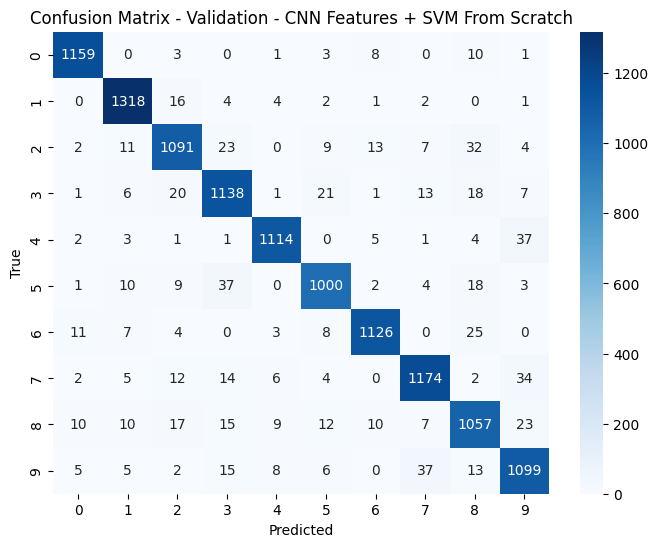

{'Accuracy': 0.9396666666666667,
 'Precision': 0.9396395415823899,
 'Recall': 0.9390483588850351,
 'F1-score': 0.9392923016516281}

In [ ]:
# =========================
# 20. SVM From Scratch on CNN Features
# =========================

cnn_svm = LinearSVMFromScratch(
    learning_rate=0.001,
    num_iterations=1500,
    reg_strength=0.001
)

cnn_svm.fit(X_train_cnn_scaled, y_cnn_train)

cnn_svm_val_results = evaluate_model(
    cnn_svm,
    X_val_cnn_scaled,
    y_cnn_val,
    dataset_name="Validation - CNN Features + SVM From Scratch"
)

cnn_svm_val_results

In [ ]:
# =========================
# 21. Learning Curves
# =========================

train_sizes = [1000, 3000, 6000, 10000, 20000, 40000]

learning_curve_results = []

for size in train_sizes:
    print(f"Training size: {size}")

    X_subset = X_train_scaled[:size]
    y_subset = y_train[:size]

    model = SoftmaxRegression(
        learning_rate=0.1,
        num_iterations=500,
        reg_strength=0.001
    )

    model.fit(X_subset, y_subset)

    train_pred = model.predict(X_subset)
    val_pred = model.predict(X_val_scaled)

    train_acc = accuracy_score(y_subset, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    learning_curve_results.append({
        "Training Size": size,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)
learning_curve_df

Training size: 1000
Iteration 0: Loss = 2.3027
Training size: 3000
Iteration 0: Loss = 2.3027
Training size: 6000
Iteration 0: Loss = 2.3027
Training size: 10000
Iteration 0: Loss = 2.3027
Training size: 20000
Iteration 0: Loss = 2.3027
Training size: 40000
Iteration 0: Loss = 2.3027


,Training Size,Train Accuracy,Validation Accuracy
0,1000,1.00000,0.863917
1,3000,0.96900,0.892417
2,6000,0.94700,0.903250
3,10000,0.93490,0.907583
4,20000,0.92710,0.912667
5,40000,0.92195,0.914167


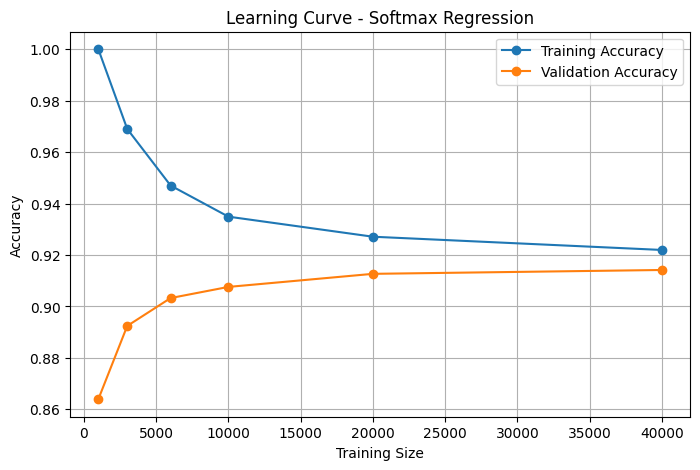

In [ ]:
# =========================
# 22. Plot Learning Curves
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    learning_curve_df["Training Size"],
    learning_curve_df["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    learning_curve_df["Training Size"],
    learning_curve_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Learning Curve - Softmax Regression")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================
# FINAL MODEL COMPARISON
# =========================

final_comparison_df = pd.DataFrame([
    {
        "Model": "Softmax Regression",
        "Feature": "Raw Pixels",
        "Improvement": "Regularization + CV",
        **tuned_softmax_val_results
    },
    {
        "Model": "Linear SVM",
        "Feature": "Raw Pixels",
        "Improvement": "Cross-Validation",
        **tuned_svm_val_results
    },
    {
        "Model": "Random Forest",
        "Feature": "Raw Pixels",
        "Improvement": "Ensemble",
        **rf_val_results
    },
    {
        "Model": "Linear SVM",
        "Feature": "CNN Features",
        "Improvement": "CNN Feature Extraction",
        **cnn_svm_val_results
    }
])

final_comparison_df = final_comparison_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

final_comparison_df

,Model,Feature,Improvement,Accuracy,Precision,Recall,F1-score
0,Linear SVM,CNN Features,CNN Feature Extraction,0.939667,0.939640,0.939048,0.939292
1,Softmax Regression,Raw Pixels,Regularization + CV,0.917250,0.916696,0.916277,0.916343
2,Linear SVM,Raw Pixels,Cross-Validation,0.906667,0.906198,0.905553,0.905632
3,Random Forest,Raw Pixels,Ensemble,0.834000,0.834998,0.830788,0.830553


In [ ]:
best_model_name = final_comparison_df.iloc[0]["Model"]
best_feature = final_comparison_df.iloc[0]["Feature"]

print("Best Model:", best_model_name)
print("Best Feature:", best_feature)

Best Model: Linear SVM
Best Feature: CNN Features


In [ ]:
# =========================
# Combine Train + Validation
# =========================

X_train_val_scaled = np.vstack((X_train_scaled, X_val_scaled))
y_train_val = np.hstack((y_train, y_val))

print("Train + Validation shape:", X_train_val_scaled.shape)
print("Train + Validation labels:", y_train_val.shape)

Train + Validation shape: (60000, 784)
Train + Validation labels: (60000,)


Raw train+val: (60000, 784) (60000,)
CNN train+val: (27000, 1280) (27000,)
Iteration 0: Loss = 8.9938
Iteration 500: Loss = 0.4392
Iteration 1000: Loss = 0.3519
Iteration 1500: Loss = 0.3102

Evaluation on Test - Final CNN + SVM
---------------------------------------------
Accuracy : 0.9502
Precision: 0.9500
Recall   : 0.9496
F1-score : 0.9498

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.93      0.94      0.93      1032
           3       0.92      0.95      0.93      1010
           4       0.96      0.96      0.96       982
           5       0.95      0.93      0.94       892
           6       0.97      0.96      0.96       958
           7       0.95      0.95      0.95      1028
           8       0.93      0.92      0.92       974
           9       0.94      0.92      0.93      1009

    accuracy                     

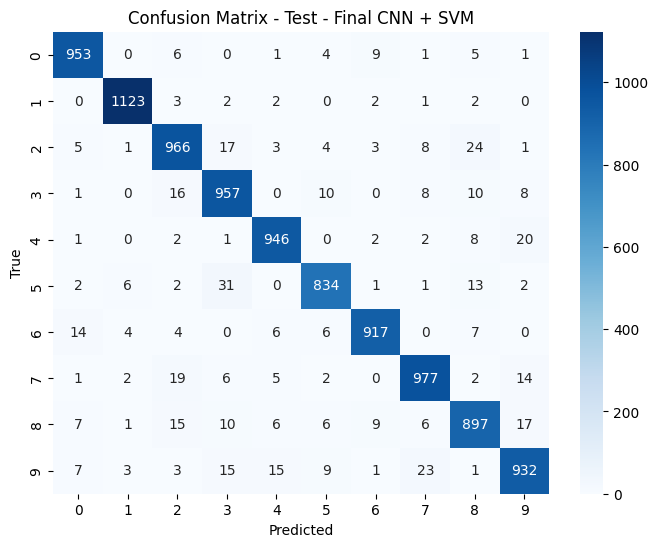

{'Accuracy': 0.9502,
 'Precision': 0.9499870801191561,
 'Recall': 0.9495988244576692,
 'F1-score': 0.9497511623889006}

In [ ]:
# =========================
# FINAL MODEL TRAINING + TEST
# =========================

# Raw feature train + validation
X_train_val_scaled = np.vstack((X_train_scaled, X_val_scaled))
y_train_val = np.hstack((y_train, y_val))

# CNN feature train + validation
X_train_val_cnn = np.vstack((X_train_cnn_scaled, X_val_cnn_scaled))
y_train_val_cnn = np.hstack((y_cnn_train, y_cnn_val))

print("Raw train+val:", X_train_val_scaled.shape, y_train_val.shape)
print("CNN train+val:", X_train_val_cnn.shape, y_train_val_cnn.shape)

if best_model_name == "Softmax Regression":

    final_model = SoftmaxRegression(
        learning_rate=best_softmax_lr,
        num_iterations=1500,
        reg_strength=best_softmax_reg
    )

    final_model.fit(X_train_val_scaled, y_train_val)

    final_test_results = evaluate_model(
        final_model,
        X_test_scaled,
        y_test,
        dataset_name="Test - Final Softmax Regression"
    )

elif best_model_name == "Linear SVM" and best_feature == "Raw Pixels":

    final_model = LinearSVMFromScratch(
        learning_rate=best_svm_lr,
        num_iterations=2000,
        reg_strength=best_svm_reg
    )

    final_model.fit(X_train_val_scaled, y_train_val)

    final_test_results = evaluate_model(
        final_model,
        X_test_scaled,
        y_test,
        dataset_name="Test - Final Linear SVM (Raw)"
    )

elif best_model_name == "Linear SVM" and best_feature == "CNN Features":

    final_model = LinearSVMFromScratch(
        learning_rate=0.001,
        num_iterations=2000,
        reg_strength=0.001
    )

    final_model.fit(X_train_val_cnn, y_train_val_cnn)

    final_test_results = evaluate_model(
        final_model,
        X_test_cnn_scaled,
        y_test,
        dataset_name="Test - Final CNN + SVM"
    )

elif best_model_name == "Random Forest":

    final_model = RandomForestFromScratch(
        n_trees=5,
        max_depth=8,
        min_samples_split=10,
        max_features=50
    )

    final_model.fit(X_train_val_scaled, y_train_val)

    final_test_results = evaluate_model(
        final_model,
        X_test_scaled,
        y_test,
        dataset_name="Test - Final Random Forest"
    )

final_test_results

In [ ]:
# =========================
# Final Test Result Table
# =========================

final_test_df = pd.DataFrame([{
    "Final Model": best_model_name,
    "Feature Type": best_feature,
    "Accuracy": final_test_results["Accuracy"],
    "Precision": final_test_results["Precision"],
    "Recall": final_test_results["Recall"],
    "F1-score": final_test_results["F1-score"]
}])

final_test_df

,Final Model,Feature Type,Accuracy,Precision,Recall,F1-score
0,Linear SVM,CNN Features,0.9502,0.949987,0.949599,0.949751


In [ ]:
# =========================
# Save Results
# =========================

final_comparison_df.to_csv("phase2_validation_comparison.csv", index=False)
final_test_df.to_csv("phase2_final_test_results.csv", index=False)
reg_results_df.to_csv("phase2_regularization_bias_variance.csv", index=False)
learning_curve_df.to_csv("phase2_learning_curve.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
